# Notebook e reprodutibilidade

As dependências exata do ambiente Julia está em `Manifest.toml`e `Project.toml`. Em _teoria_ o pacote `StableRNG` deve garantir que as figuras sejam reprodutivas.

In [2]:
using CairoMakie
using Distributions
using Random
using Statistics
using StableRNGs
rng = StableRNG(123456789)

StableRNGs.LehmerRNG(state=0x0000000000000000000000000eb79a2b)

# Questão 10

### a) 
Uma gaussiana é a uma distribuição de probabilidades "bem comportadas" em termos de momentos, a integral de $x^ne^{x^{-2}/2}$ devido a sua rápida queda, converge para qualquer $n \in \mathbb{R}$. Portanto, é esperado que a média amostral se aproxime da média teórica conforme $n \to \infty$.

Já para a distribuição de Cauchy que não tem esperança bem definida, é esperado que a média não convirja e somente oscile aleatóriamente  

### b)

Como esperado, a gaussiana de fato se aproximou de ter $\mu=0$ e $\sigma=1$ enquanto a a distribuição de Cauchy demonstrou o seu caráter patológico. É interessante ver que o desvio padrão oscilou por uma ordem de grandeza a mais do que a média, provavelmente por envolver termos ao quadrado

Gaussiana média final = -0.0007357748550939578
Gaussiana desvio padrão final = 0.9876842296969667


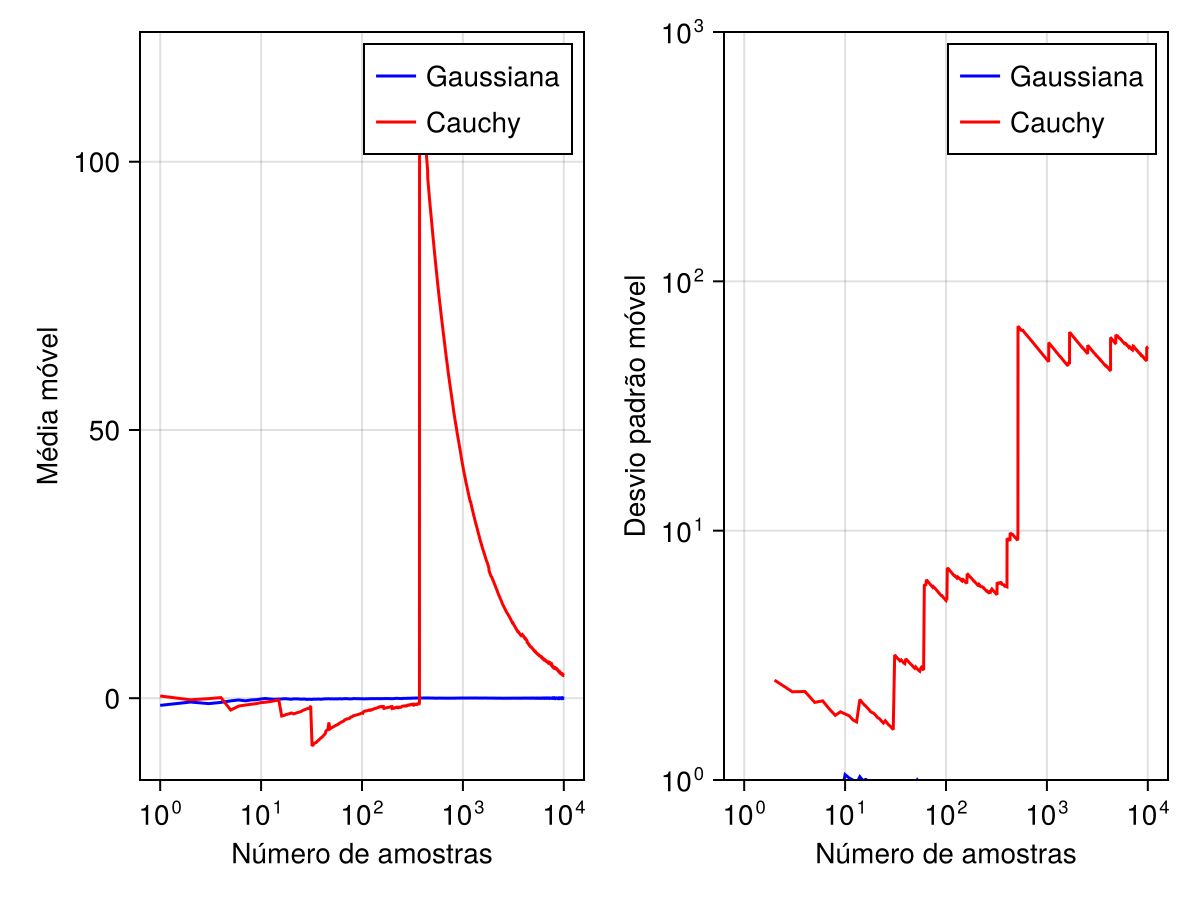

In [3]:
#Para o código ser eficiente, vamos usar dois truques para
# calcularmos a média e o desvio padrão acumulados em O(n)

#μₙ = μₙ₋₁ + (xₙ - μₙ₋₁) / n.
function running_mean(values)
    Iterators.accumulate(enumerate(values); init=0.0) do μ, (n, x)
        μ + (x - μ) / n
    end
end

#Var(X) = E[X²] - E[X]²
function running_std(values)
    means = running_mean(values)
    mean_squares = running_mean(x^2 for x in values)
    Iterators.map(zip(means, mean_squares)) do (μ, μ₂)
        sqrt(μ₂ - μ^2)
    end
end
N=10_000

gauss=Normal(0.0,1.0)
cauchy=Cauchy(0.0,1.0)
fig=Figure()
ax_mean=Axis(fig[1,1],xscale=log10,xlabel="Número de amostras",ylabel="Média móvel")
ax_std=Axis(fig[1,2],xscale=log10,yscale=log10,xlabel="Número de amostras",ylabel="Desvio padrão móvel")
means_gauss=collect(running_mean(rand(rng,gauss,N)))
means_cauchy=collect(running_mean(rand(rng,cauchy,N)))

lines!(ax_mean,1:N,means_gauss,label="Gaussiana",color=:blue)
lines!(ax_mean,1:N,means_cauchy,label="Cauchy",color=:red)

stds_gauss=collect(running_std(rand(rng,gauss,N)))
stds_cauchy=collect(running_std(rand(rng,cauchy,N)))
lines!(ax_std,1:N,stds_gauss,label="Gaussiana",color=:blue)
lines!(ax_std,1:N,stds_cauchy,label="Cauchy",color=:red)
println("Gaussiana média final = $(means_gauss[end])")
println("Gaussiana desvio padrão final = $(stds_gauss[end])")
axislegend(ax_mean)
axislegend(ax_std)
fig


## c)


Conforme $n$ cresce, o desvio padrão das médias das gaussinas se aproxima de zero, o que significa
que a média empiríca se aproxima da teórica. Já a distribuição de Cauchy não se aproxima de nada 







In [19]:
function ex10_c_figures(medida_centralidade)
    repetitions=100
    fig_gauss=Figure()
    Label(
        fig_gauss[0, :],
        "Distribuição Gaussiana";
        fontsize=24,
        font=:bold,
    )
    axes_gauss = [
        Axis(fig_gauss[row, column])
        for row in 1:2, column in 1:2
    ]
    linkxaxes!(axes_gauss...)
    linkyaxes!(axes_gauss...)

    fig_cauchy=Figure()
    Label(fig_cauchy[0,:],
        "Distribuição Cauchy",
        fontsize=24,
        font=:bold

    )

    axes_cauchy = [
        Axis(fig_cauchy[row, column])
        for row in 1:2, column in 1:2
    ]

    linkxaxes!(axes_cauchy...)
    linkyaxes!(axes_cauchy...)
    for (ax_gauss,ax_cauchy,n) in zip(axes_gauss,axes_cauchy,[100,1_000,10_000,100_000])
        amostras_gauss=rand(rng,gauss,(n,repetitions))
        amostras_cauchy=rand(rng,cauchy,(n,repetitions))
        hist!(ax_gauss,vec(medida_centralidade(amostras_gauss,dims=1)),label="n=$n",color=:blue)
        hist!(ax_cauchy,vec(medida_centralidade(amostras_cauchy,dims=1)),label="n=$n",color=:red)
        axislegend(ax_gauss)
        axislegend(ax_cauchy)
    end
    (;fig_gauss,fig_cauchy)
end 
ex10_c=ex10_c_figures(mean)

(fig_gauss = Scene(9 children, 0 plots), fig_cauchy = Scene(9 children, 0 plots))

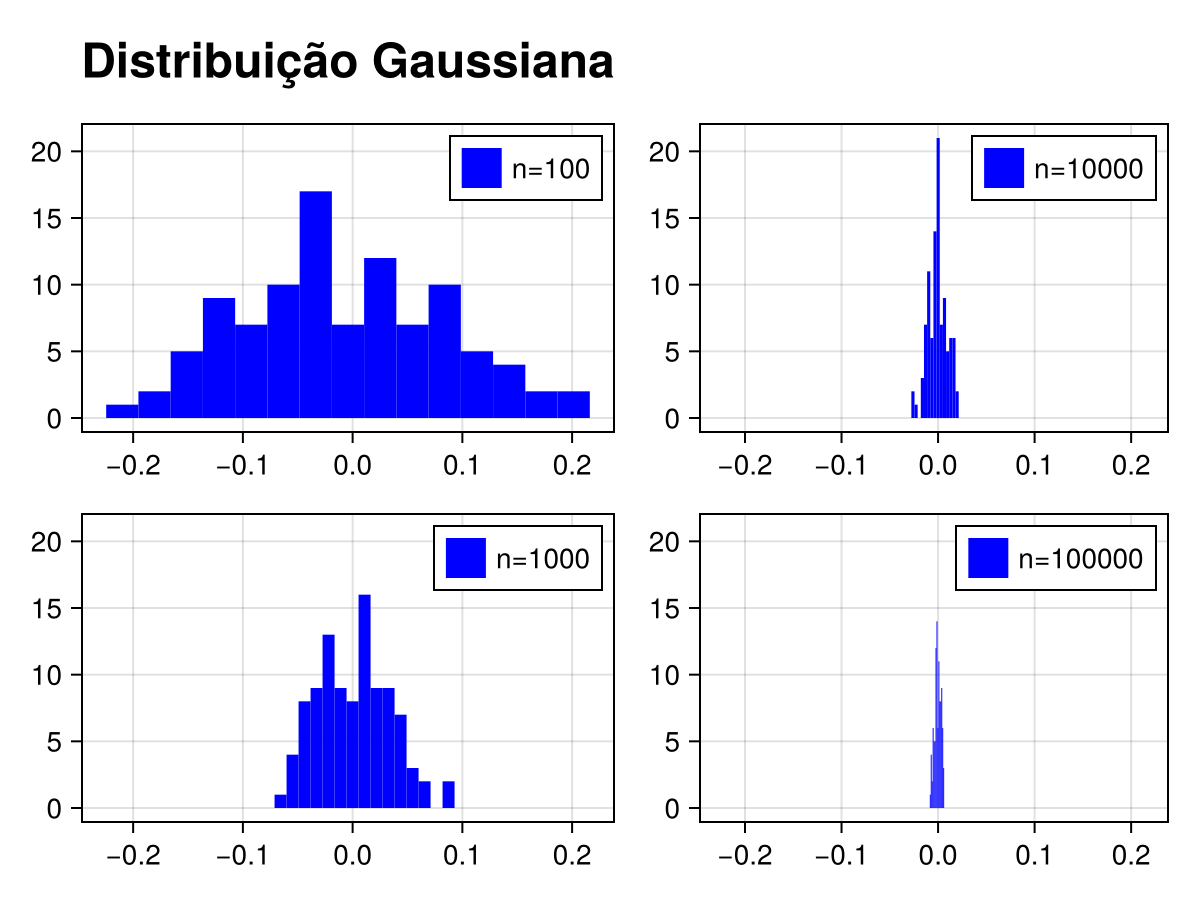

In [20]:
ex10_c.fig_gauss

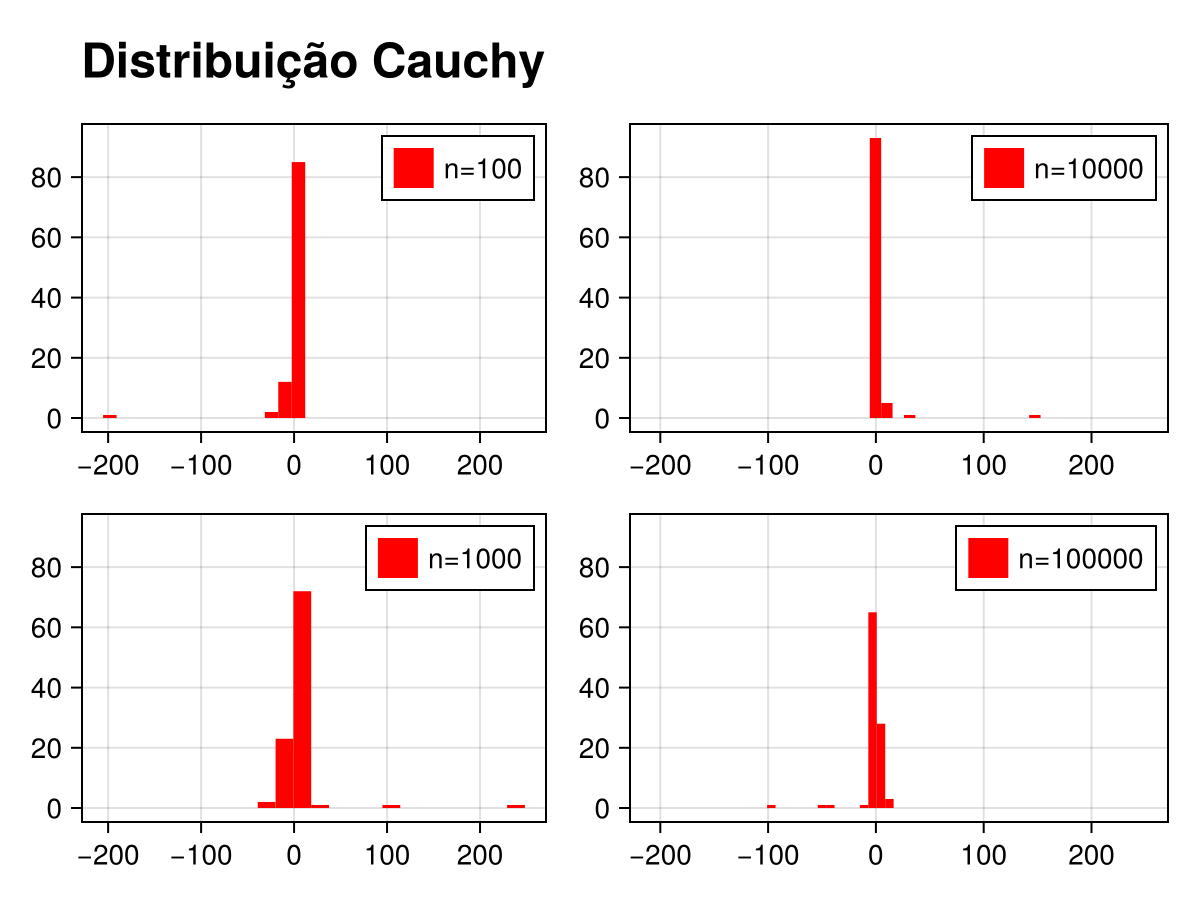

In [21]:
ex10_c.fig_cauchy

## d) 
O fato de a distribuição Gaussiana se estreitar é esperado pela Lei Dos Grandes Números, é fácil demonstrar que a média empiríca também segue uma distribuição gaussiana que o desvio padrão cai com $\frac{1}{\sqrt{N}}$ usando o fato que a soma de duas gaussianas é uma gaussiana ($\mathcal{N}(\mu_a,\sigma_a^2)+\mathcal{N}(\mu_b,\sigma_b^2)=\mathcal{N}(\mu_a+\mu_b,\sigma_a^2+\sigma_b^2)$)

$$X \sim \mathcal{N}(\mu,\sigma^2)$$

$$\frac{1}{N} \sum_i X_i=\frac{1}{N} X(N\mu,N*\sigma^2)=X(\mu,\sigma^2/N)$$

Como o próprio anunciado afirma, a média de uma distribuição de Cauchy é a própria distribuição de Cauchy, conforme $N \to \infty$ ela não se estreita, o que implica que a média empirica não converge.

## e)
Usando a mediana, o que se observa é que como ambas as distribuições são simétricas, é esperado
o mesmo número de elementos positivos e negativos, a mediana se aproxima de zero conforme $N \to \infty$,
o que faz com que a distribuição de Cauchy nesse caso tenha mediana amostral convergindo para zero

In [22]:
ex10_d=ex10_c_figures(median)

(fig_gauss = Scene(9 children, 0 plots), fig_cauchy = Scene(9 children, 0 plots))

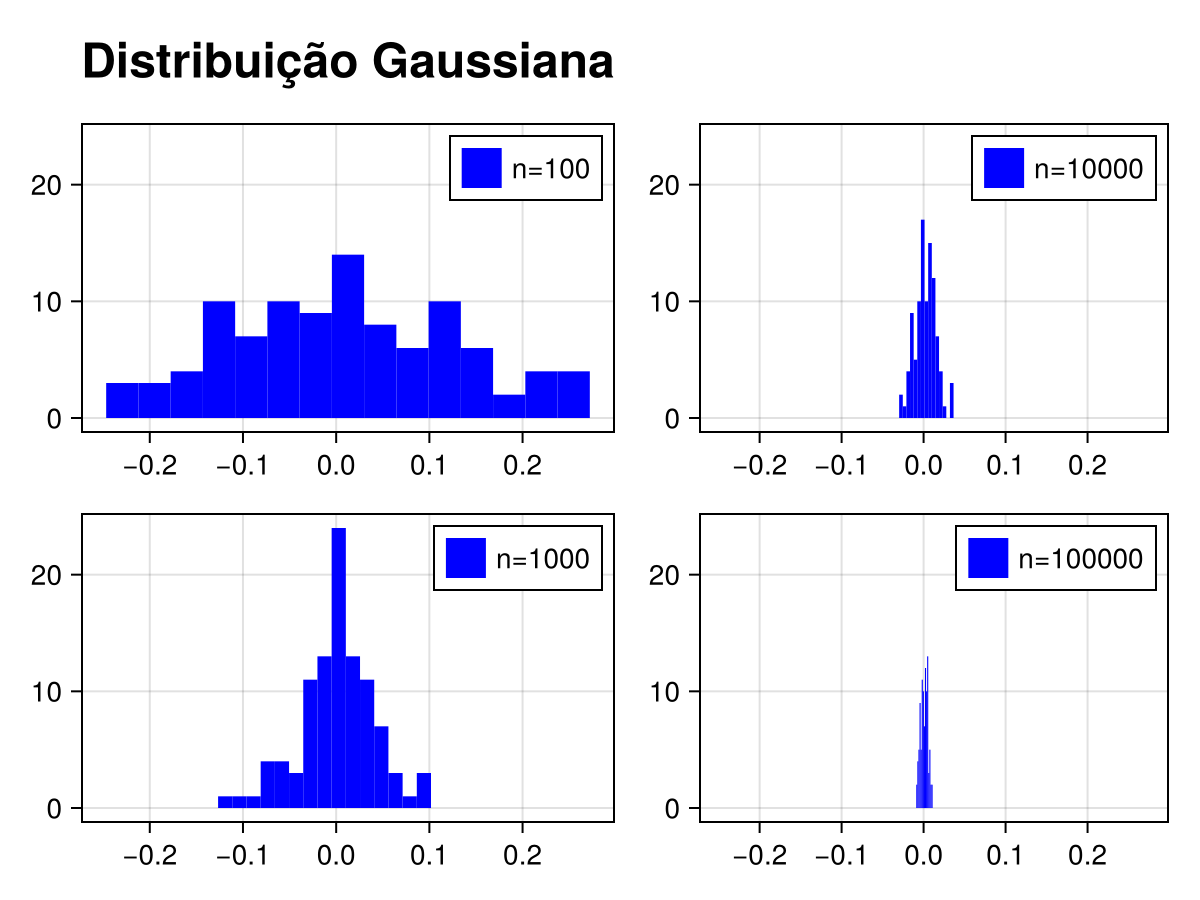

In [23]:
ex10_d.fig_gauss

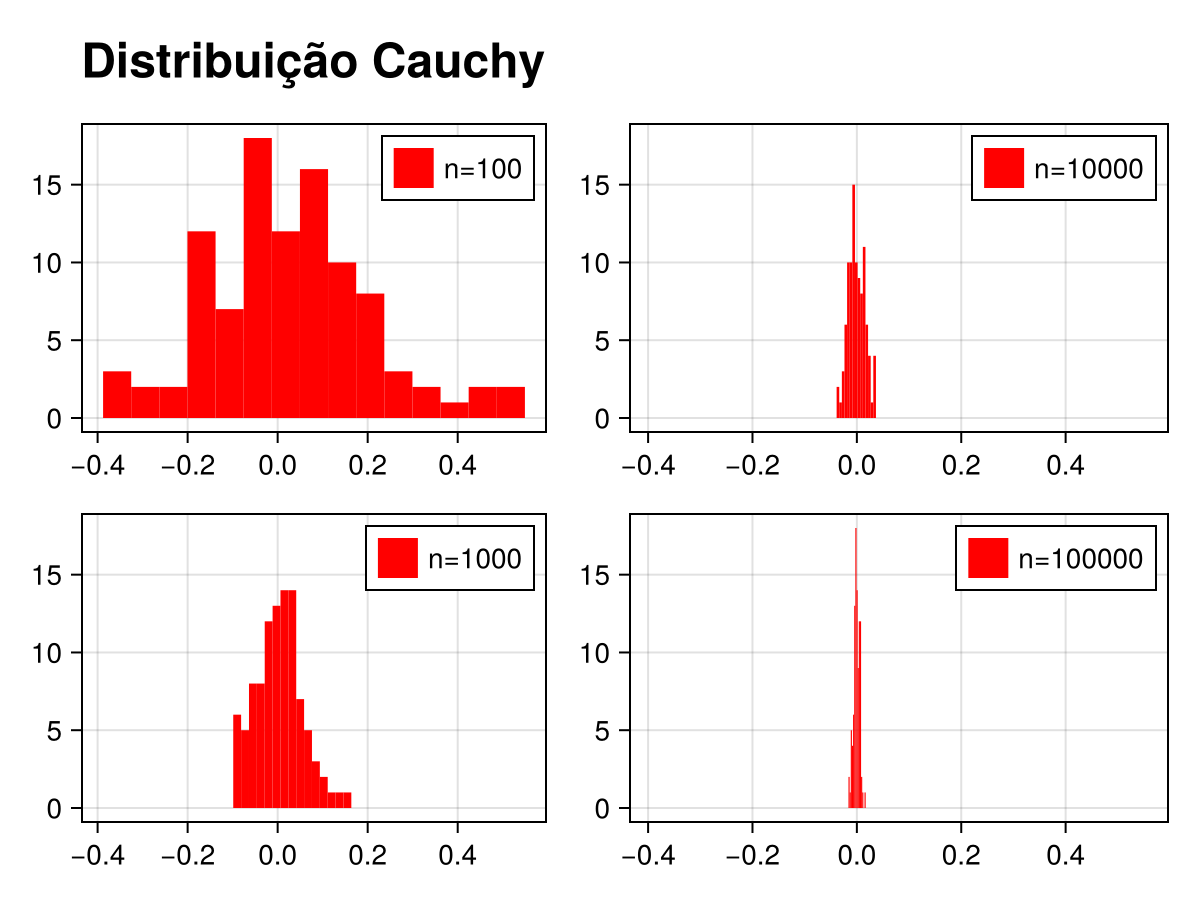

In [24]:
ex10_d.fig_cauchy

# Questão 11

## a)

Executando nove vezes com $n=1000$ se observa uma variação grande, algumas realizações de fato com média próxima de zero, outras claramente deslocadas para o lado positivo/negativo

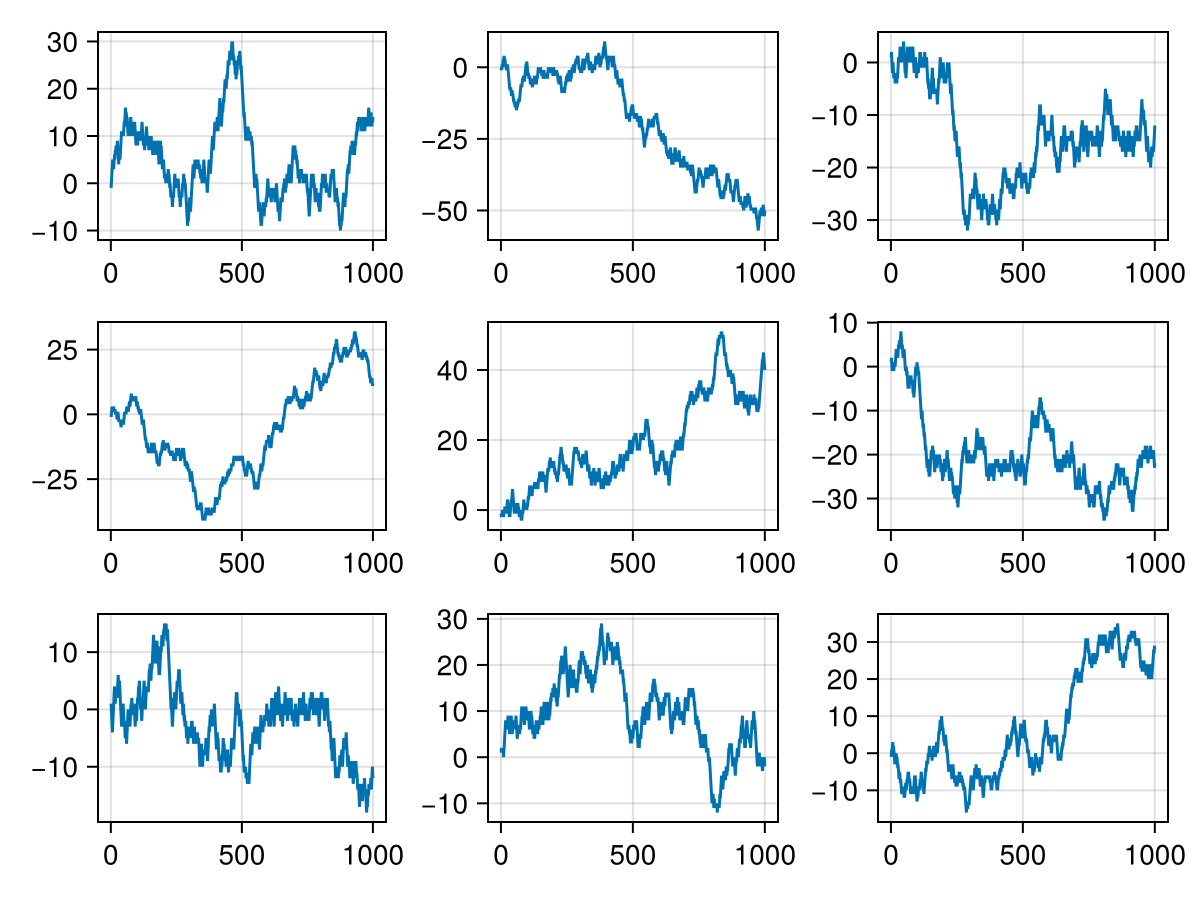

In [6]:
Y = DiscreteNonParametric([-1, 1], [0.5, 0.5])
fig=Figure()
n=1000
for i=1:3, j=1:3
    lines(fig[i,j],1:n,cumsum(rand(rng,Y,n)))
end
fig

## b) 

Como

$$
P(Y_i=1)=P(Y_i=-1)=\frac12,
$$

temos

$$
E[Y_i] = \frac12(1)+\frac12(-1) =
0.
$$

Além disso,

$$
\operatorname{Var}(Y_i) = E[Y_i^2]-E[Y_i]^2 =
1.
$$

Como

$$
X_n=\sum_{i=1}^n Y_i,
$$

pela linearidade da esperança,

$$
E[X_n] = \sum_{i=1}^n E[Y_i] = 0.
$$

Como as variáveis $Y_i$ são independentes, suas variâncias são aditivas:

$$
\operatorname{Var}(X_n) =
\sum_{i=1}^n \operatorname{Var}(Y_i) = n.
$$

Portanto, embora a esperança de $X_n$ permaneça igual a zero,
sua variância cresce linearmente com $n$. Consequentemente,$\sigma_{X_n}=\sqrt{n}$, isso explica as grandes flutuações

## c)

### Demostrando relação $X_n=2*K_n-n$
Chamando o conjunto de dias em alta de $A=\{i \in [1,...,n] | Y_i=1\}$, os dias de baixa são claramente $A^c$.
Como há $K_n$ de alta e $n-K_n$ de baixa, a soma total é os dias de alta
menos os dias de baixa $$X_n=K_n -(n-K_n)=2*K_n -n$$

### Distribuição de $K_n$
Isolando o $K_n$ da equação anterior
$$K_n=(X_n+n)/2$$
$$K_n=\sum_i ((Y_i +1)/2)$$

Vamos chamar $Z_i=(Y_i+1)/2$, temos que $P(Z_i=0)=P(Z_i=1)=1/2$, o que significa que Z $\sim$ Bernoulli(P=1/2).


$$K_n=\sum_i Z_i=\sum_i Bernoulli(p=1/2)=Binomial(N,p=1/2)$$

Portanto, $K_n$ $\sim$ Binomial(N,p=1/2).

### Expressão $P(X_n=x)$
Basta fazer $x=2*K_n-n$, $K_n=(x+n)/2$, o valor $k$ da distribuição de Binomial deve ser $(x+n)/2$. 

$$P(X=x)=\binom{n}{(x+n)/2}*(1/2)^{n}$$

Algo importante é que (x+n)/2 precisa ser um inteiro, por tanto x+n precisa ser par, $X_n$ não é exatamente uma binomial


## d)

###
Como $X_n=2*K_n-n$, $var(X_n)=var(2*K_n-n)=var(2*K_n)=4*var(K_n)$.

Portanto, $\sigma(X_n)=2*\sigma(K_n)$, $K_n$ é uma binomial, então $\sigma(K_n)=\sqrt{n*p*(1-p)}$.


Conforme o número de amostras cresce, o desvio padrão empirício se aproxima do teorico de $\sqrt{n}$

Os gráficos mostrados abaixo simplesmente colocam a distribuição P(X=x) encontrada analíticamente
em cima da encontrada computacionalmente

amostras 10 std_empirico=3.16 std_teorico=3.16
amostras 100 std_empirico=9.98 std_teorico=10.00
amostras 1000 std_empirico=31.36 std_teorico=31.62
amostras 10000 std_empirico=100.84 std_teorico=100.00


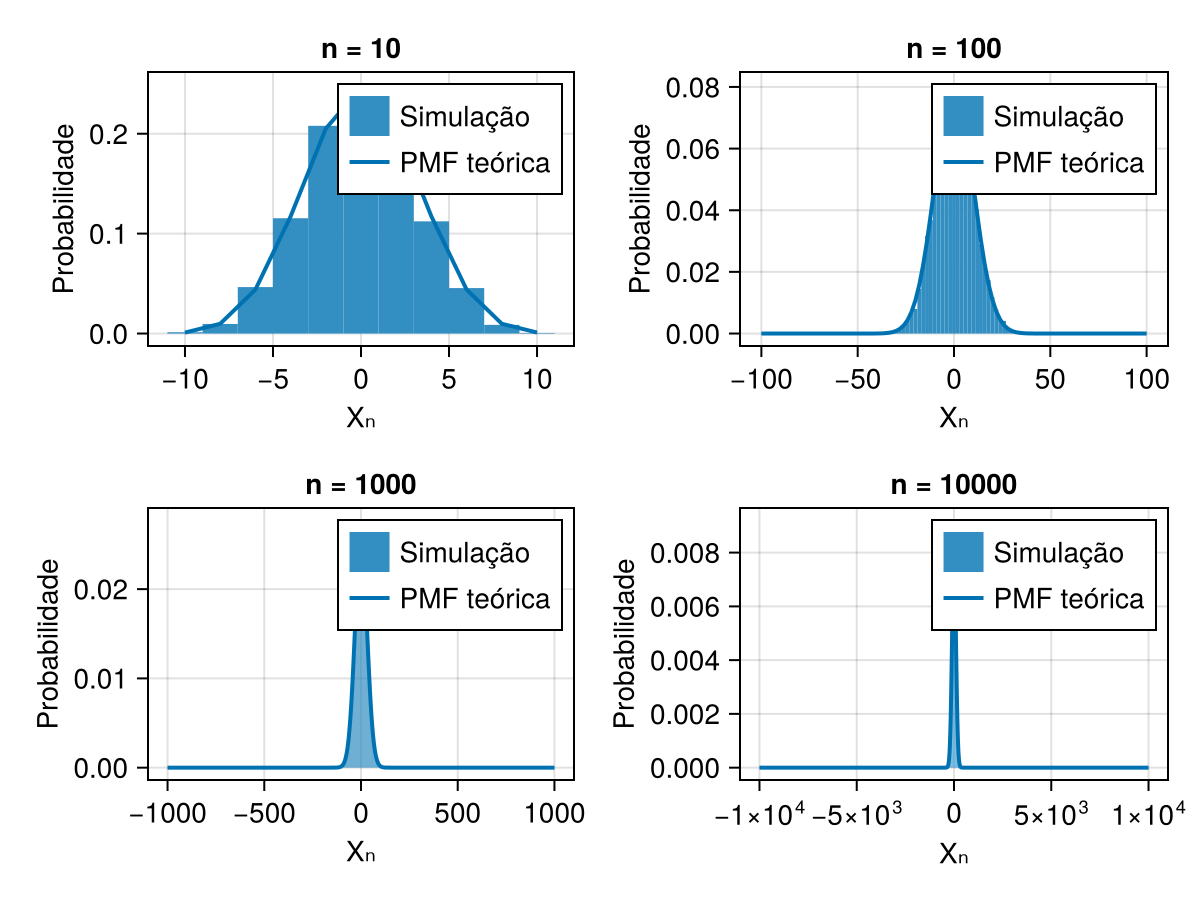

In [ ]:
using Printf

X(n) = sum(rand(rng, Y, n))

ns = [10, 100, 1000, 10_000]
repetitions = 10_000

x_values = [
    [X(n) for _ in 1:repetitions]
    for n in ns
]

for (n, x) in zip(ns, x_values)
    @printf "amostras %d std_empirico=%.2f std_teorico=%.2f\n" n std(x) sqrt(n)
end

fig = Figure(scale=(3840,2160))

positions = [
    (1, 1),
    (1, 2),
    (2, 1),
    (2, 2),
]

for ((row, col), n, samples) in zip(positions, ns, x_values)
    ax = Axis(
        fig[row, col];
        title = "n = $n",
        xlabel = "Xₙ",
        ylabel = "Probabilidade",
    )
    bins = (-n - 1):2:(n + 1)

    hist!(
        ax,
        samples;
        bins,
        normalization = :probability,
        label = "Simulação",
    )
    x = -n:2:n
    k = (x .+ n) ./ 2
    p = pdf.(Binomial(n, 0.5), k)
    lines!(
        ax,
        x,
        p;
        linewidth = 2,
        label = "PMF teórica",
    )
    axislegend(ax)
end

fig

## Questão 12